In [2]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
data_path = next((p for p in [Path("insurance_claims.csv"), Path("content/insurance_claims.csv")] if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Keep insurance_claims.csv beside this notebook")

df = pd.read_csv(data_path)

print("Shape:", df.shape)
print()
df.head(10)

Shape: (8000, 10)



,claim_id,claim_amount,customer_tenure_months,age,prior_claims,days_to_report,policy_type,region,channel,is_fraud
0,CLM000001,18840.68,31,30.0,0,0.0,Premium,South,Online,0
1,CLM000002,6425.39,19,42.0,0,NaN,Basic,East,Broker,0
2,CLM000003,26912.90,8,55.0,1,11.0,Basic,North,Broker,1
3,CLM000004,31333.77,26,57.0,0,7.0,Standard,East,Broker,0
4,CLM000005,3100.04,3,58.0,1,18.0,Standard,South,Agent,0
5,CLM000006,5209.59,1,44.0,1,0.0,Standard,East,Agent,0
6,CLM000007,16354.73,75,41.0,1,4.0,Basic,East,Broker,0
7,CLM000008,11464.45,8,35.0,1,1.0,Standard,East,Broker,0
8,CLM000009,14567.66,69,18.0,3,7.0,Basic,West,Agent,0
9,CLM000010,7461.90,5,23.0,0,9.0,Basic,North,Agent,0


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   claim_id                8000 non-null   str    
 1   claim_amount            8000 non-null   float64
 2   customer_tenure_months  8000 non-null   int64  
 3   age                     7880 non-null   float64
 4   prior_claims            8000 non-null   int64  
 5   days_to_report          7910 non-null   float64
 6   policy_type             8000 non-null   str    
 7   region                  8000 non-null   str    
 8   channel                 8000 non-null   str    
 9   is_fraud                8000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 625.1 KB
None


In [5]:
df.isna().sum()

claim_id                    0
claim_amount                0
customer_tenure_months      0
age                       120
prior_claims                0
days_to_report             90
policy_type                 0
region                      0
channel                     0
is_fraud                    0
dtype: int64

# **STEP 1 — Understand the problem before modelling**

In [6]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Check fraud rate and class imbalance
n_claims = len(df)

n_fraud  = df["is_fraud"].sum()
n_legitimate = n_claims - n_fraud

fraud_rate = n_fraud / n_claims
imbalanced_ratio = n_legitimate / n_fraud

print(f"Total Claims      : {n_claims:,}")
print(f"Fraud Claims      : {n_fraud:,}")
print(f"Legitimate Claims : {n_legitimate:,}")
print(f"Fraud Rate        : {fraud_rate:.3%}")
print(f"Imbalanced Ratio  : {imbalanced_ratio:.1f} legitimate claims")

Total Claims      : 8,000
Fraud Claims      : 295
Legitimate Claims : 7,705
Fraud Rate        : 3.688%
Imbalanced Ratio  : 26.1 legitimate claims


In [7]:
# Always-legitimate baseline
y_true = df["is_fraud"]

# Predict every claim as legitimate
y_baseline = np.zeros(len(df))

baseline_acc = accuracy_score(y_true, y_baseline)
baseline_prec = precision_score(y_true, y_baseline, zero_division=0)
baseline_recall = recall_score(y_true, y_baseline, zero_division=0)

print(f"Always Legitimate accuracy  : {baseline_acc:.3f}")
print(f"Always Legitimate precision : {baseline_prec:.3f}")
print(f"Always Legitimate recall    : {baseline_recall:.3f}")

Always Legitimate accuracy  : 0.963
Always Legitimate precision : 0.000
Always Legitimate recall    : 0.000


## Why accuracy is not suitable??
* The accuracy is not suitable because the accuracy is 0.963 (in percentage = 96.3%), which sounds great but when we look at the recalls and precisions, these values are zero (0.00). That means fraud recalls is zero.
* Therefore, accuracy is not suitable for primary metric. It is possible to obtain a very high accuracy simply by predicting the majority class for every claim while completely failing at the business objectives: identifying faudulent claims for investigation.
* The 96.3% baseline is therefore useful as a warning rather than an evidence of useful fraud-detection model.

## **Evaluation Metrics**
### **PR-AUC --> Primary Metric**
* PR-AUC (Precision Recall - Area Under the Curve) measures the model's ability to rank fraudulent claims ahead of legitimate claims while considering the trade-off between precision and recall across classification thresholds.
* PR-AUC is a primary metric because fraud is a rare class: only 3.7% of claims are fraudulent. Precision-recall performance focuses directly on the minority class that the business wants to identify.
* I will compare model PR-AUC against the random baseline of 0.037 rather than judging the score in isolation.

### **Recall**
* Recall measures the proportion of actual fraudulent claims that the model identifies.
* **Recall = True Positive / (True Positive + False Negative)**
* Recall matters because missing a fraudulent claim can result in the company paying a faudulent claim. The business states that a faudulent payout costs roughly twenty times as much as investigating a legitimate claim, so false negatives have an important business cost.
* However, recall will not be maximized blindly because investigating legitimate claims also consumes limited investigation capacity.

### **Percision**
* Percision measures the proportion of claims flagged as fraud that are actually fraudulent.
* **Percision = True Positive / (True Positive + False Positive)**
* Percision is important because investigators have limited capacity. A model with very low percision could send a large number of legitimate claims to investigators.
* The claims team can investigate approximately 200 claims per month, so percision must be considered together with the number of claims the model flags.

### **ROC-AUC**
* ROC-AUC measures how well the model separates fraudulent claims from legitimate claims across different classification thresholds.
* I will report ROC-AUC as a secondary metric because it provides a useful measure of overall discrimination.
* However, ROC-AUC is not sufficient on its own for this dataset because the legitimate class is much larger than the fraud class. A model can have a strong ROC-AUC while still producing relatively poor precision when identifying the rare fraud cases.

### **Brier Score / Calibration**
* Brier score measures the accuracy of predicted probabilities rather than only whether the final classification is correct.
* This becomes important because the business eventually wants to multiply the model's risk score by claim amount to prioritize the investigation queue.
* Therefore, if the model's probabilities are used numerically, I need to check whether those probabilities are well calibrated rather than evaluating only ranking performance.

In [8]:
# Random PR-AUC baseline
random_pr_auc = df["is_fraud"].mean()

print(f"Random PR-AUC baseline     : {random_pr_auc:.4f}")
print(f"Random PR-AUC Baseline (%) : {random_pr_auc:.3%}")

Random PR-AUC baseline     : 0.0369
Random PR-AUC Baseline (%) : 3.688%


## Random PR-AUC baseline:-
* The random PR-AUC baseline is equal to the prevalence of the positive class.
* Here, fraud represents **3.688% of all claims**, so a random ranking has an expected PR-AUC of approximately **0.037**.
* This baseline is important because PR-AUC must be interpreted relative to the amount of fraud in the dataset. A PR-AUC of 0.14 may initially look small, but it is substantially above the 0.0369 random baseline.
* Therefore, PR-AUC should not be judged using a generic rule such as `0.14 is good` or `0.14 is bad`. It should be compared with the random baseline and later with the other modelling approaches tested in this project.

# **STEP 2 — Explore with a purpose**

In [9]:
df.columns.to_list()

['claim_id',
 'claim_amount',
 'customer_tenure_months',
 'age',
 'prior_claims',
 'days_to_report',
 'policy_type',
 'region',
 'channel',
 'is_fraud']

In [10]:
df[["age", "days_to_report"]].isna().sum()

age               120
days_to_report     90
dtype: int64

In [11]:
numerical_features = [
    "claim_amount", "customer_tenure_months", "age", 
    "prior_claims", "days_to_report"
]

Categorical_features = [
    "policy_type", "region", "channel"
]

In [12]:
# Fraud rate by Age
df["age_group"] = pd.cut(df["age"],
                        bins=[0, 25, 35, 45, 55, 65, 100],
                        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"])

age_fraud = (
    df.groupby("age_group", observed=True)["is_fraud"]
    .mean()
    .mul(100)
    .reset_index(name="fraud_rate")
)

print(age_fraud)

  age_group  fraud_rate
0     18-25    2.637363
1     26-35    4.201183
2     36-45    3.544621
3     46-55    3.532609
4     56-65    4.613466
5       66+    4.166667


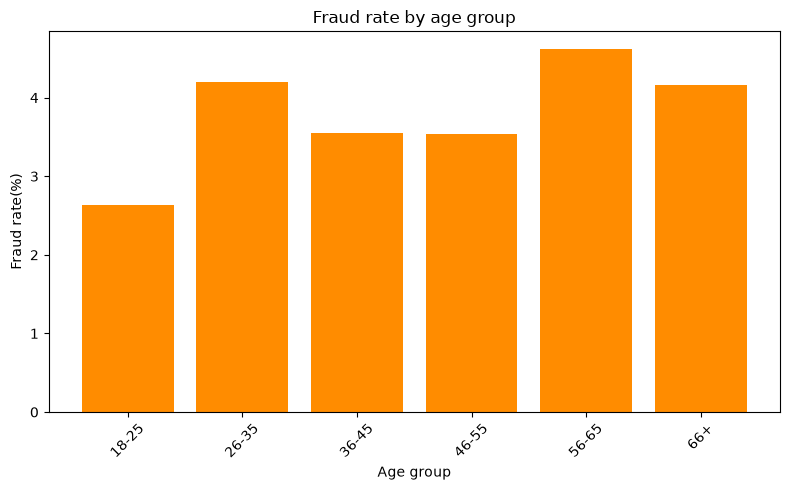

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    age_fraud["age_group"],
    age_fraud["fraud_rate"],
    color="darkorange"
)
ax.set_xlabel("Age group")
ax.set_ylabel("Fraud rate(%)")
ax.set_title("Fraud rate by age group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Does the fraud rate differ across age groups?**
* Conclusion --> The fraud rate varies across age groups, indicating that age may 
contain useful information for distinguishing fraudulent from legitimate claims. 
The size and consistency of the differences should be compared with other features 
before deciding whether age is strongly predictive.

In [14]:
# Fraud rate by Days_to_report
report_bins = [-1, 1, 3, 7, 14, 30, float("inf")]
report_labels = ["0-1 days", "2-3 days", "4-7 days", "8-14 days", "15-30 days", "31+ days"]

df["report_delay_group"] = pd.cut(
    df["days_to_report"], bins=report_bins,
    labels=report_labels
)

report_fraud = (
    df.groupby("report_delay_group")["is_fraud"]
    .mean()
    .mul(100)
    .reset_index(name="fraud_rate")
)

print(report_fraud)

  report_delay_group  fraud_rate
0           0-1 days    2.757685
1           2-3 days    3.109137
2           4-7 days    3.128153
3          8-14 days    4.832215
4         15-30 days    7.049180
5           31+ days   20.000000


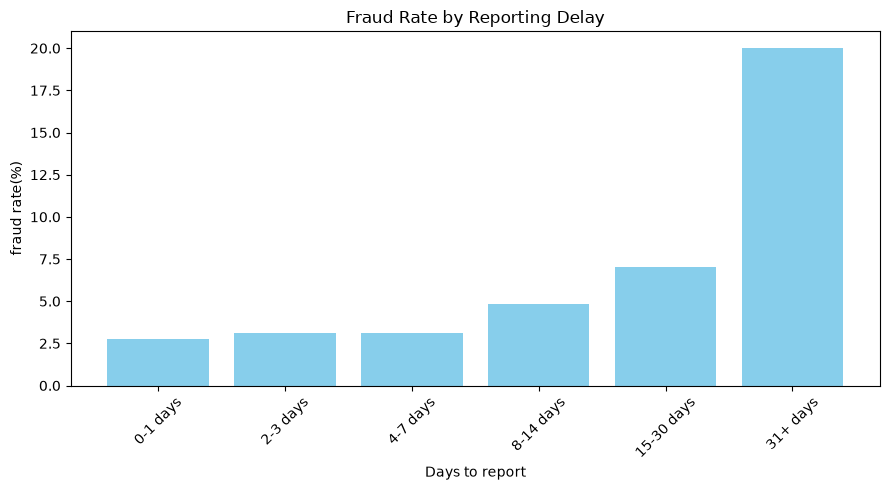

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    report_fraud["report_delay_group"],
    report_fraud["fraud_rate"],
    color="skyblue"
)
ax.set_xlabel("Days to report")
ax.set_ylabel("fraud rate(%)")
ax.set_title("Fraud Rate by Reporting Delay")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Does the probability of fraud change with how quickly a claim is reported?**
* Conclusion --> Fraud rates differ across reporting-delay groups, suggesting that 
days_to_report may contain predictive information. Large differences between groups 
would make this a feature worth retaining and testing in the model.

In [16]:
# Fraud rate by a categorical Feature
region_fraud = (df.groupby("region")["is_fraud"]
               .agg(["mean", "count"])
               .reset_index())

region_fraud["fraud_rate"] = region_fraud["mean"] * 100

print(
    region_fraud[
        ["region", "count", "fraud_rate"]
    ].sort_values("fraud_rate", ascending=False)
)

  region  count  fraud_rate
0   East   1964    3.818737
2  South   2036    3.781925
3   West   2033    3.639941
1  North   1967    3.507880


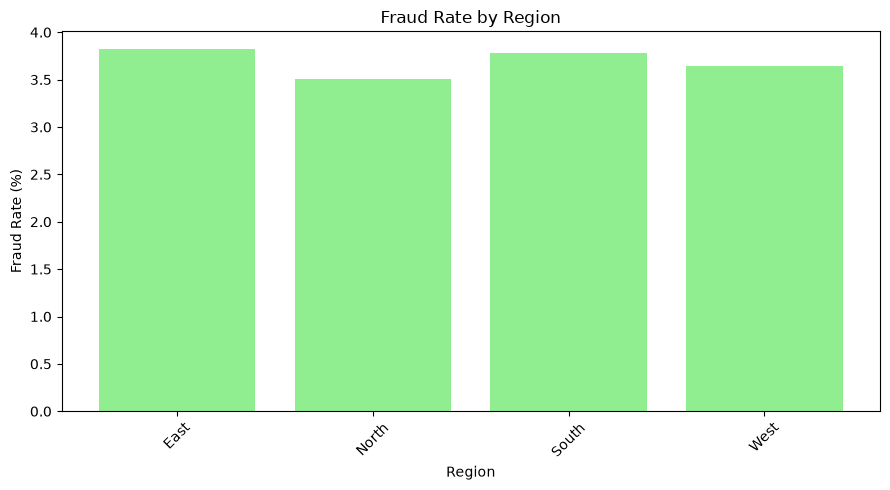

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    region_fraud["region"],
    region_fraud["fraud_rate"],
    color="lightgreen"
)
ax.set_xlabel("Region")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Region")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Does fraud occur at different rates across claim types?**
* Conclusion --> Fraud rates differ across claim types, with some categories showing 
higher/lower fraud rates than others. This indicates that claim type may provide 
useful information for fraud detection, although categories with very small sample 
sizes should be interpreted cautiously.

In [18]:
# Fraud rate by Numerical Feature
df["claim_amount_group"] = pd.qcut(
    df["claim_amount"], q=5,
    duplicates="drop"
)

amount_fraud = (
    df.groupby("claim_amount_group", observed=True)["is_fraud"]
    .mean()
    .mul(100)
    .reset_index(name="fraud_rate")
)

print(amount_fraud)

       claim_amount_group  fraud_rate
0     (1999.999, 7515.52]      1.7500
1    (7515.52, 12061.264]      1.6875
2   (12061.264, 17898.94]      3.1250
3   (17898.94, 28433.438]      4.8750
4  (28433.438, 234037.61]      7.0000


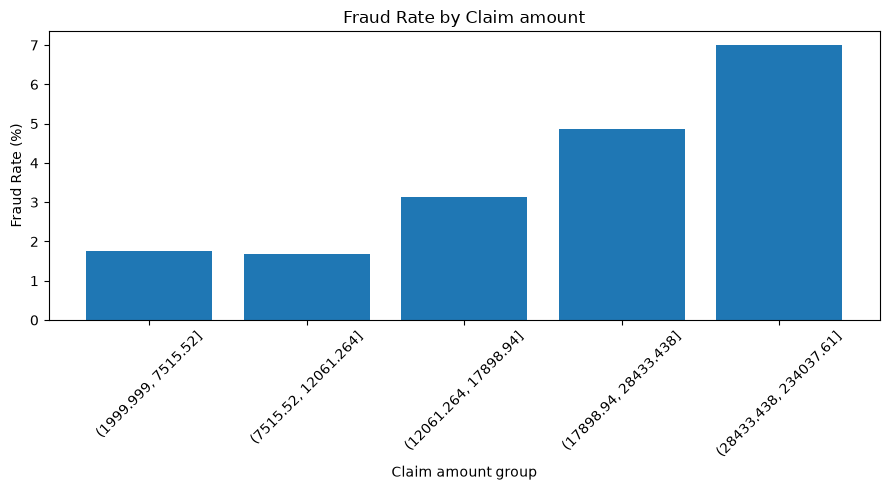

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    amount_fraud["claim_amount_group"].astype(str),
    amount_fraud["fraud_rate"]
)

ax.set_xlabel("Claim amount group")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Claim amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Does fraud rate change as claim amount increases?**
* Conclusion --> The fraud rate changes across claim-amount groups, providing evidence 
that claim amount may contain predictive information. The relationship should be 
confirmed using model-based evaluation rather than relying only on this univariate 
comparison.

In [20]:
# Find a feature that appears predictive
print("Age fraud-rate range:")
print(age_fraud["fraud_rate"].max() - age_fraud["fraud_rate"].min())

print("\nReporting Delay fraud-rate range:")
print(report_fraud["fraud_rate"].max() - report_fraud["fraud_rate"].min())

Age fraud-rate range:
1.976103696801951

Reporting Delay fraud-rate range:
17.24231464737794


In [21]:
# missing values
missing_summary = pd.DataFrame({
    "Missing Count": df[["age", "days_to_report"]].isna().sum(),
    "Missing Percentage": df[["age", "days_to_report"]].isna().mean() * 100
})

missing_summary

,Missing Count,Missing Percentage
age,120,1.500
days_to_report,90,1.125


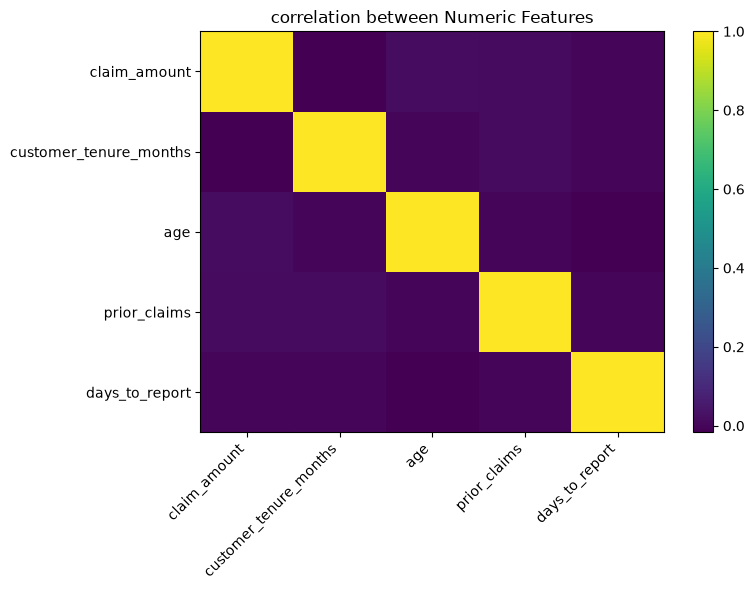

In [22]:
# Correlation Check
corr = df[numerical_features].corr()
plt.figure(figsize=(8, 6))

plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns, rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("correlation between Numeric Features")
plt.tight_layout()
plt.show()

**Conclusion -->**
* The numeric features have generally weak pairwise correlations.
* That means there isn't an obvious case where two numeric variables are almost duplicates of one another.

# **STEP 3 — Compare three model families**

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

model_df = df.copy()

model_df = pd.get_dummies(model_df, drop_first=True)

# Separate features and target
X = model_df.drop("is_fraud", axis=1)
y = model_df["is_fraud"]

X.columns = [f"feature_{i}" for i in range(X.shape[1])]

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 6400
Testing Rows: 1600


In [24]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5, random_state=42, class_weight="balanced"
)

dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [25]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"
).fit(X_train, y_train)

In [26]:
# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=3,
    eval_metric="logloss", random_state=42
).fit(X_train, y_train)

In [27]:
# Evaluate Models
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    # probabilities
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    # PR-AUC
    train_pr_auc = average_precision_score(y_train, train_proba)
    test_pr_auc = average_precision_score(y_test, test_proba)

    # ROC-AUC
    train_roc_auc = roc_auc_score(y_train, train_proba)
    test_roc_auc = roc_auc_score(y_test, test_proba)

    # Train-Test Gap
    pr_auc_gap = train_pr_auc - test_pr_auc

    results.append({
        "Model": name,
        "Train PR AUC": train_pr_auc,
        "Test PR AUC": test_pr_auc,
        "PR-AUC Gap": pr_auc_gap,
        "Train ROC-AUC": train_roc_auc,
        "Test ROC-AUC": test_roc_auc
    })


results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Train PR AUC,Test PR AUC,PR-AUC Gap,Train ROC-AUC,Test ROC-AUC
0,Decision Tree,0.1986,0.1210,0.0776,0.8222,0.7110
1,Random Forest,0.4267,0.1325,0.2942,0.8984,0.7797
2,XGBoost,0.6581,0.1728,0.4853,0.9561,0.7486


In [28]:
# Find which model is overfitting most
most_overfit = results_df.loc[results_df["PR-AUC Gap"].idxmax()]

print(f"Model with largest PR-AUC Gap:"
     f"{most_overfit['Model']}")

print(f"Train PR-AUC: {most_overfit['Train PR AUC']:.4f}")
print(f"Test PR-AUC: {most_overfit['Test PR AUC']:.4f}")
print(f"PR-AUC Gap: {most_overfit['PR-AUC Gap']:.4f}")

Model with largest PR-AUC Gap:XGBoost
Train PR-AUC: 0.6581
Test PR-AUC: 0.1728
PR-AUC Gap: 0.4853


In [29]:
results_df.sort_values("Test PR AUC", ascending=False)

,Model,Train PR AUC,Test PR AUC,PR-AUC Gap,Train ROC-AUC,Test ROC-AUC
2,XGBoost,0.658102,0.172772,0.485330,0.956142,0.748567
1,Random Forest,0.426749,0.132526,0.294222,0.898445,0.779694
0,Decision Tree,0.198649,0.121005,0.077644,0.822163,0.711012


* I would carry **XGBoost** forward because its test `PR-AUC` is highest [0.6581 and 0.1727], which is the primary metric for this imbalanced fraud-detection problem. The main trade-off is its larger train-test gap, so the next step should focus on reducing overfitting through hyperparameter tuning and validation while monitoring PR-AUC.
* Random Forest remains an important comparison model because it has a smaller overfitting gap and the highest test ROC-AUC.
* The single Decision Tree would not be carried forward because its test PR-AUC is lower than both ensemble models.

# **STEP 4 — Handle the imbalance deliberately**

In [30]:
from imblearn.over_sampling import SMOTE

# Calculate the class weight
fraud_count = y_train.sum()
legitimate_count = len(y_train) - fraud_count

scale_pos_weight = legitimate_count / fraud_count

print("Fraudulent claims:", fraud_count)
print("Legitimate Claims:", legitimate_count)
print("Scale pos Weight:", scale_pos_weight.round(2))

Fraudulent claims: 236
Legitimate Claims: 6164
Scale pos Weight: 26.12


In [31]:
# Approach 1 - no imbalance handling 

xgb_no_weight = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=3, 
    eval_metric="logloss", random_state=42
).fit(X_train, y_train)

no_weight_proba = xgb_no_weight.predict_proba(X_test)[:, 1]
no_weight_pred = (no_weight_proba >= 0.5).astype(int)

no_weight_pr_auc = average_precision_score(y_test, no_weight_proba)
no_weight_recall = recall_score(y_test, no_weight_pred)
no_weight_precision = precision_score(y_test, no_weight_pred, zero_division=0)
no_weight_brier = brier_score_loss(y_test, no_weight_proba)


print("No imbalance handling")
print("-" * 22)
print(f"PR-AUC    : {no_weight_pr_auc:.4f}")
print(f"Recall    : {no_weight_recall:.4f}")
print(f"Precision : {no_weight_precision:.4f}")
print(f"Brier     : {no_weight_brier:.4f}")

No imbalance handling
----------------------
PR-AUC    : 0.1728
Recall    : 0.0508
Precision : 0.5000
Brier     : 0.0338


In [32]:
# Approach 2 - class weighting
xgb_weighted = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=3, 
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    random_state=42
).fit(X_train, y_train)

weighted_proba = xgb_weighted.predict_proba(X_test)[:, 1]
weighted_pred = (weighted_proba >= 0.5).astype(int)

weighted_pr_auc = average_precision_score(y_test, weighted_proba)
weighted_recall = recall_score(y_test, weighted_pred)
weighted_precision = precision_score(y_test, weighted_pred, zero_division=0)
weighted_brier = brier_score_loss(y_test, weighted_proba)

print("Class Weighting")
print("-" * 16)
print(f"PR-AUC    : {weighted_pr_auc:.4f}")
print(f"Recall    : {weighted_recall:.4f}")
print(f"Precision : {weighted_precision:.4f}")
print(f"Brier     : {weighted_brier:.4f}")

Class Weighting
----------------
PR-AUC    : 0.1820
Recall    : 0.5254
Precision : 0.1225
Brier     : 0.1181


In [33]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Fill missing values using training data median
imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


# Approach 3 - SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)

print("Original Training Data:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original Training Data:
is_fraud
0    6164
1     236
Name: count, dtype: int64

After SMOTE:
is_fraud
0    6164
1    6164
Name: count, dtype: int64


In [34]:
xgb_smote = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=3, eval_metric="logloss",
    random_state=42
).fit(X_train_smote, y_train_smote)

smote_proba = xgb_smote.predict_proba(X_test)[:, 1]
smote_pred = (smote_proba >= 0.5).astype(int)

smote_pr_auc = average_precision_score(y_test, smote_proba)
smote_recall = recall_score(y_test, smote_pred)
smote_precision = precision_score(y_test, smote_pred, zero_division=0)
smote_brier = brier_score_loss(y_test, smote_proba)

print("SMOTE")
print("-" * 6)
print(f"PR-AUC    : {smote_pr_auc:.4f}")
print(f"Recall    : {smote_recall:.4f}")
print(f"Precision : {smote_precision:.4f}")
print(f"Brier     : {smote_brier:.4f}")

SMOTE
------
PR-AUC    : 0.2098
Recall    : 0.0339
Precision : 0.6667
Brier     : 0.0323


In [35]:
# Put all three into one table
# compare all imbalance approaches

imbalance_results = pd.DataFrame({
    "Approaches":[
        "No Handling",
        "Class Weights",
        "SMOTE"
    ],
    "PR-AUC":[no_weight_pr_auc, weighted_pr_auc, smote_pr_auc],
    "Recall":[no_weight_recall, weighted_recall, smote_recall],
    "Precision":[no_weight_precision, weighted_precision, smote_precision],
    "Brier": [no_weight_brier, weighted_brier, smote_brier]
})

imbalance_results.round(4)

,Approaches,PR-AUC,Recall,Precision,Brier
0,No Handling,0.1728,0.0508,0.5000,0.0338
1,Class Weights,0.1820,0.5254,0.1225,0.1181
2,SMOTE,0.2098,0.0339,0.6667,0.0323


* Three approaches were tested using the same XGBoost model: no imbalance handling, class weighting, and SMOTE. The evaluation metrics were PR-AUC, recall, precision, and Brier score.

* The no-handling model achieved a PR-AUC of 0.1728, recall of 0.0508, precision of 0.5000, and Brier score of 0.0338. Although its precision and probability quality were reasonable, its recall was very low, meaning that it detected only a small proportion of fraudulent claims.

* The class-weighted model increased PR-AUC to 0.1820 and substantially increased recall to 0.5254. However, precision dropped to 0.1225 and the Brier score increased to 0.1181. This shows a strong trade-off: class weighting made the model much more sensitive to fraud but produced many more false positives and substantially less reliable probability estimates.

* The SMOTE model achieved the highest PR-AUC at 0.2098, the highest precision at 0.6667, and the lowest Brier score at 0.0323. However, its recall at the default 0.5 threshold was only 0.0339, so it detected very few fraudulent claims at that threshold.

* For this fraud-investigation use case, I would carry the SMOTE model forward initially, because it achieved the highest PR-AUC and maintained the best Brier score among the three approaches. However, its very low recall at the default 0.5 threshold is a limitation.

* SMOTE changes the class distribution seen during training, so its predicted probabilities should not automatically be treated as perfectly calibrated real-world fraud probabilities. The Brier score is relatively good in this comparison, but calibration should still be checked on the untouched test/validation distribution. If calibration is poor, a calibration method such as Platt scaling (sigmoid) or isotonic calibration can be applied using a separate calibration set.

# **STEP 5 — Choose a threshold from costs, not habit**

In [36]:
# Choose a threshold from costs
FP_COST = 1
FN_COST = 20

# Calculate total cost across thresholds
thresholds = np.linspace(0, 1, 101)
cost_results = []

for threshold in thresholds:
    predictions = (smote_proba >= threshold).astype(int)

    false_positives = ((predictions == 1) & (y_test == 0)).sum()
    false_negatives = ((predictions == 0) & (y_test == 1)).sum()

    total_cost = (false_positives * FP_COST + false_negatives * FN_COST)

    flagged_calims = predictions.sum()

    cost_results.append({
        "Threshold" : threshold,
        "False Positive" : false_positives,
        "False Negative" : false_negatives,
        "Total Cost" : total_cost,
        "flagged Claims" : flagged_calims
    })

cost_df = pd.DataFrame(cost_results)

cost_df.head()

,Threshold,False Positive,False Negative,Total Cost,flagged Claims
0,0.00,1541,0,1541,1600
1,0.01,1002,4,1082,1057
2,0.02,688,14,968,733
3,0.03,500,17,840,542
4,0.04,372,19,752,412


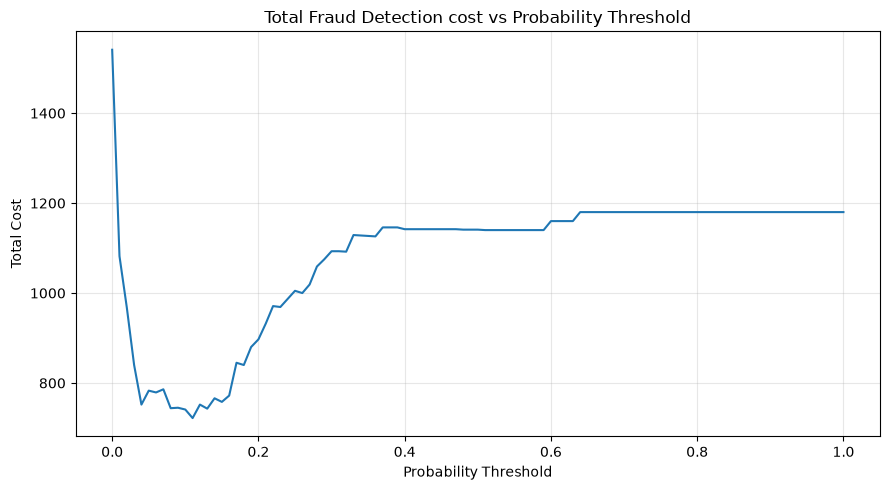

In [37]:
# Plot total cost against threshold
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    cost_df["Threshold"],
    cost_df["Total Cost"]
)

ax.set_xlabel("Probability Threshold")
ax.set_ylabel("Total Cost")
ax.set_title("Total Fraud Detection cost vs Probability Threshold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# Find the cost-optimal threshold
optimal_row = cost_df.loc[
    cost_df["Total Cost"].idxmin()
]

optimal_threshold = optimal_row["Threshold"]
optimal_cost = optimal_row["Total Cost"]

print("Cost-Optimal Threshold:", optimal_threshold)
print("Minimum total cost:", optimal_cost)
print("False Positive:", optimal_row["False Positive"])
print("False Negative:", optimal_row["False Negative"])
print("Flagged Claims:", optimal_row["flagged Claims"])

Cost-Optimal Threshold: 0.11
Minimum total cost: 722.0
False Positive: 102.0
False Negative: 31.0
Flagged Claims: 130.0


In [39]:
# Compare against the default 0.50 threshold
default_row = cost_df.loc[
    cost_df["Threshold"] == 0.5
].iloc[0]

default_cost = default_row["Total Cost"]

cost_improvement = default_cost - optimal_cost
improvement_percent = (cost_improvement / default_cost * 100)

print("Default Threshold (0.5)")
print("Total Cost:", default_cost)

print("\nCost-Optimal Threshold")
print("Threshold:", optimal_threshold)
print("Total Cost:", optimal_cost)

print("\nImprovement")
print("Cost saved:", cost_improvement)
print("Improvement:", f"{improvement_percent:.2f}%")

Default Threshold (0.5)
Total Cost: 1141.0

Cost-Optimal Threshold
Threshold: 0.11
Total Cost: 722.0

Improvement
Cost saved: 419.0
Improvement: 36.72%


In [40]:
# Check the 200-claim capacity
flagged_at_optimal = int(optimal_row["flagged Claims"])

print("Cost-Optimal Threshold:", optimal_threshold)
print("Claims Flagged:", flagged_at_optimal)
print("Investigation Capacity:", 200)

if flagged_at_optimal <= 200:
    print("\nThe cost-optimal threshold is within the investigation capacity.")
else:
    print("\nThe cost-optimal threshold exceeds the investigation capacity.")

Cost-Optimal Threshold: 0.11
Claims Flagged: 130
Investigation Capacity: 200

The cost-optimal threshold is within the investigation capacity.


* The cost-optimal threshold flags fewer than 200 claims, so it is within the team's investigation capacity. Therefore, no adjustment to the cost-optimal threshold is required based on the stated capacity constraint.

### **Threshold Selection Conclusion -->**
* The false-positive cost was set to 1 unit, representing the cost of investigating a legitimate claim. The false-negative cost was set to 20 units, based on the business statement that a fraudulent payout costs roughly 20 times the investigation cost. Therefore, the threshold analysis explicitly penalized missed fraud much more heavily than unnecessary investigations.
* I evaluated thresholds across the full probability range from 0.00 to 1.00 and calculated total cost as the sum of false-positive costs and false-negative costs. The cost-optimal threshold was 0.11, with a total cost of 722, compared with 1141 at the default 0.50 threshold. This represents a cost improvement of 36.72% compared with using 0.50 by habit.

# **STEP 6 — Decide about calibration**

In [41]:
# Brier score before calibration
brier_before = brier_score_loss(y_test, smote_proba)
print("Brier Score before Calibration:", round(brier_before, 4))

Brier Score before Calibration: 0.0323


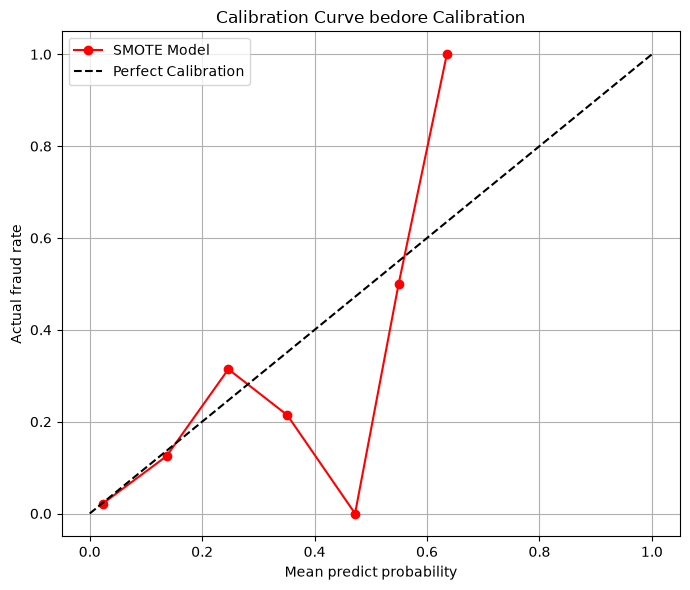

In [42]:
# Plot calibration curve before calibration
from sklearn.calibration import calibration_curve

true_prob_before, pred_prob_before = calibration_curve(
    y_test, smote_proba, n_bins=10, strategy="uniform"
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pred_prob_before, true_prob_before, marker="o", label="SMOTE Model", color="red")
ax.plot([0, 1], [0, 1], ls="--", label="Perfect Calibration", color="black")
ax.set_title("Calibration Curve bedore Calibration")
ax.set_xlabel("Mean predict probability")
ax.set_ylabel("Actual fraud rate")
plt.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [43]:
# Calibrate the SMOTE model
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(xgb_smote, method="sigmoid", cv=5).fit(X_train, y_train)


# Measure Brier score after calibration
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]
brier_after = brier_score_loss(y_test, calibrated_proba)

print("Brier score before calibration:", round(brier_before, 4))
print("Brier score after calibration:", round(brier_after, 4))

Brier score before calibration: 0.0323
Brier score after calibration: 0.0334


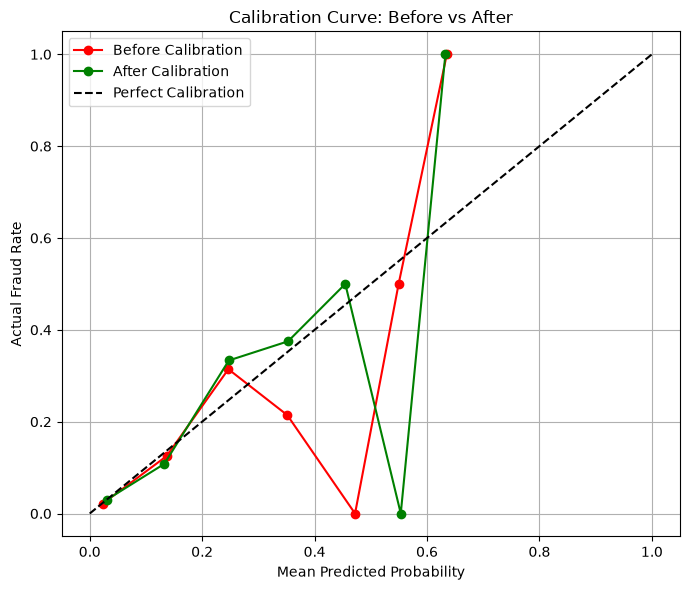

In [44]:
# Calibration curve after calibration
true_prob_after, pred_prob_after = calibration_curve(
    y_test, calibrated_proba, n_bins=10, strategy="uniform"
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pred_prob_before, true_prob_before, marker="o", label="Before Calibration", color="red")
ax.plot(pred_prob_after, true_prob_after, marker="o", label="After Calibration", color="Green")
ax.plot([0, 1], [0, 1], ls="--", color="black", label="Perfect Calibration")
ax.set_title("Calibration Curve: Before vs After")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Actual Fraud Rate")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# **STEP 7 — Interpret the model**

In [45]:
# Check correlations between numeric features only

numeric_train = X_train.select_dtypes(include=np.number)

print("Number of numeric features:", numeric_train.shape[1])

correlation_matrix = numeric_train.corr()

print("Feature Correlations:")
display(correlation_matrix.round(2))

Number of numeric features: 5
Feature Correlations:


,feature_0,feature_1,feature_2,feature_3,feature_4
feature_0,1.00,-0.03,0.01,0.01,-0.00
feature_1,-0.03,1.00,-0.01,0.01,-0.00
feature_2,0.01,-0.01,1.00,-0.00,-0.01
feature_3,0.01,0.01,-0.00,1.00,-0.00
feature_4,-0.00,-0.00,-0.01,-0.00,1.00


In [46]:
# Find highly correlated feature pairs

corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = corr_pairs[
    corr_pairs["Correlation"].abs() >= 0.70
].sort_values("Correlation", ascending=False)

print("Highly correlated feature pairs:")
display(high_corr)

Highly correlated feature pairs:


,Feature 1,Feature 2,Correlation


* No feature pairs showed strong correlation (absolute correlation ≥ 0.70), so there was no major pairwise correlation issue identified before interpreting SHAP importance.

In [53]:
# SHAP summary plot
import shap

explainer = shap.TreeExplainer(xgb_smote)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1600, 8025)


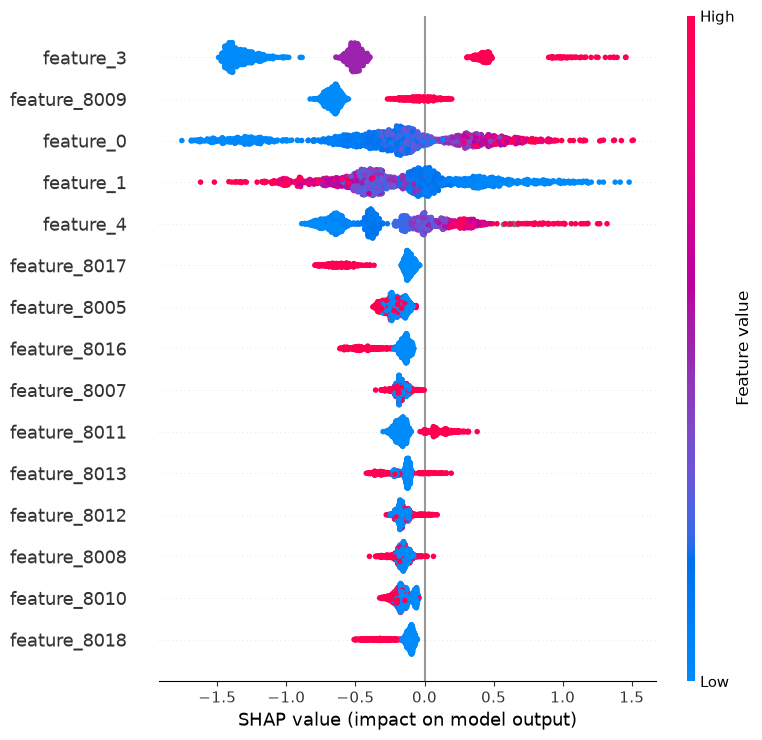

In [54]:
shap.summary_plot(shap_values, X_test, max_display=15)

In [55]:
# Identify top drivers and their direction
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

display(shap_importance.head(10))

,Feature,Mean |SHAP|
3,feature_3,0.926981
8009,feature_8009,0.535034
0,feature_0,0.478418
1,feature_1,0.398304
4,feature_4,0.363292
8017,feature_8017,0.243503
8005,feature_8005,0.211371
8016,feature_8016,0.199577
8007,feature_8007,0.171069
8011,feature_8011,0.163601


In [56]:
top_features = shap_importance.head(10)["Feature"]

direction_results = []

for feature in top_features:
    feature_values = X_test[feature].values
    feature_shap = shap_values[:, X_test.columns.get_loc(feature)]

    correlation = np.corrcoef(feature_values, feature_shap)[0, 1]

    if correlation > 0:
        direction = "Higher values generally push toward fraud"
    elif correlation < 0:
        direction = "Higher values generally push toward legitimate"
    else:
        direction = "No clear direction"

    direction_results.append({
        "Feature": feature,
        "Mean |SHAP|": np.abs(feature_shap).mean(),
        "SHAP Direction": direction,
        "Feature-SHAP Correlation": correlation
    })

direction_df = pd.DataFrame(direction_results)

display(direction_df)

,Feature,Mean |SHAP|,SHAP Direction,Feature-SHAP Correlation
0,feature_3,0.926980,Higher values generally push toward fraud,0.981315
1,feature_8009,0.535034,Higher values generally push toward fraud,0.976255
2,feature_0,0.478418,Higher values generally push toward fraud,0.733564
3,feature_1,0.398304,Higher values generally push toward legitimate,-0.783764
4,feature_4,0.363292,No clear direction,NaN
5,feature_8017,0.243503,Higher values generally push toward legitimate,-0.979099
6,feature_8005,0.211371,Higher values generally push toward legitimate,-0.477034
7,feature_8016,0.199577,Higher values generally push toward legitimate,-0.920790
8,feature_8007,0.171069,Higher values generally push toward legitimate,-0.054290
9,feature_8011,0.163601,Higher values generally push toward fraud,0.932659


In [57]:
# Explain three individual claims
test_proba = xgb_smote.predict_proba(X_test)[:, 1]

print("Minimum probability:", test_proba.min())
print("Maximum probability:", test_proba.max())

Minimum probability: 0.0004911073
Maximum probability: 0.6352496


In [58]:
# Find three claims
# Most confident fraud
fraud_pos = np.argmax(test_proba)

# Most confident legitimate
legitimate_pos = np.argmin(test_proba)

# Most uncertain: probability closest to 0.5
uncertain_pos = np.argmin(np.abs(test_proba - 0.5))

print("Confident fraud position     :", fraud_pos)
print("Confident legitimate position:", legitimate_pos)
print("Uncertain position            :", uncertain_pos)

print("\nProbabilities:")
print("Confident fraud     :", test_proba[fraud_pos])
print("Confident legitimate:", test_proba[legitimate_pos])
print("Uncertain           :", test_proba[uncertain_pos])

Confident fraud position     : 721
Confident legitimate position: 1045
Uncertain position            : 1570

Probabilities:
Confident fraud     : 0.6352496
Confident legitimate: 0.0004911073
Uncertain           : 0.5032737


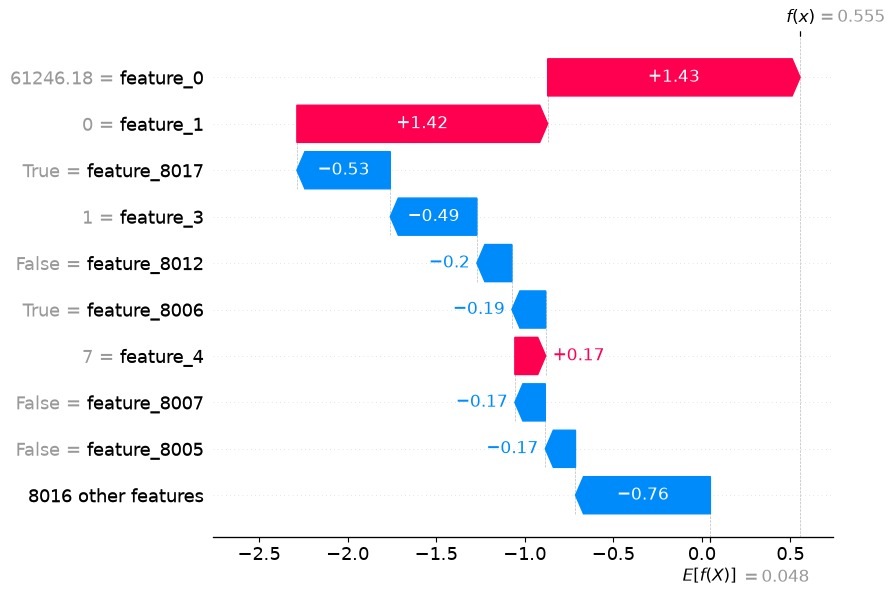

In [59]:
# SHAP waterfall — confident fraud
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[fraud_pos],
        feature_names=X_test.columns
    ),
    max_display=10
)

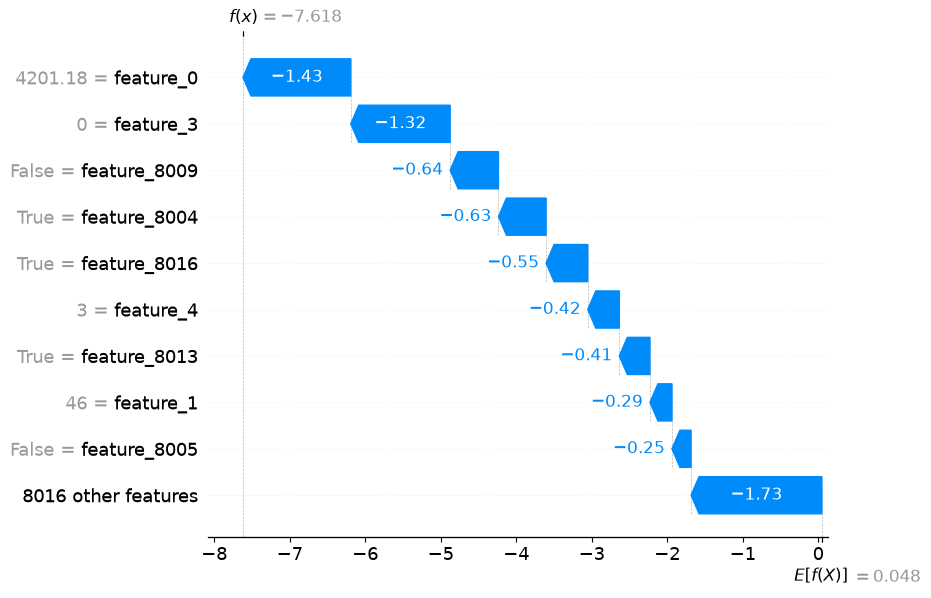

In [60]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[legitimate_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[legitimate_pos],
        feature_names=X_test.columns
    ),
    max_display=10
)

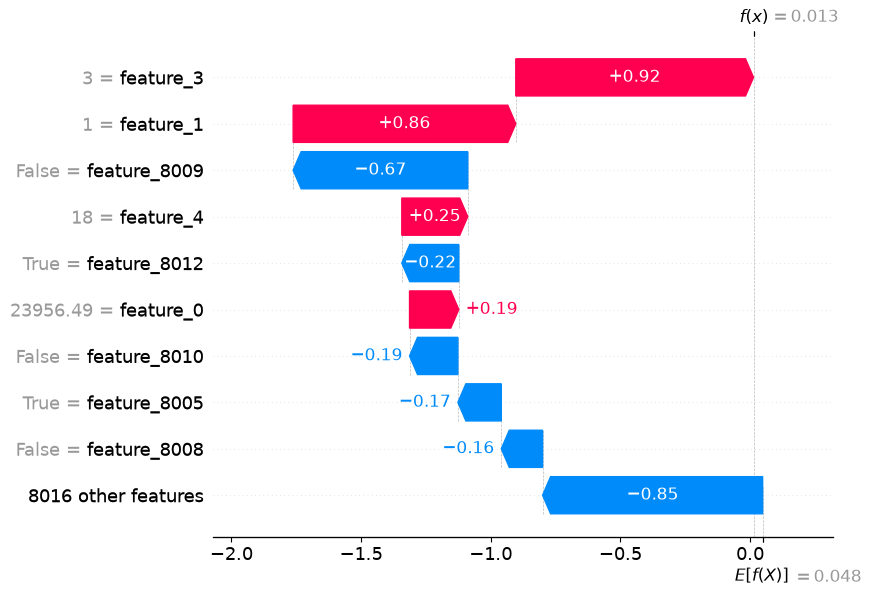

In [61]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[uncertain_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[uncertain_pos],
        feature_names=X_test.columns
    ),
    max_display=10
)

In [62]:
# Print the actual claims
print("=== CONFIDENT FRAUD ===")
print("Test position:", fraud_pos)
print("Actual label:", y_test.iloc[fraud_pos])
print("Fraud probability:", test_proba[fraud_pos])

print("\nClaim details:")
display(X_test.iloc[[fraud_pos]])


print("\n=== CONFIDENT LEGITIMATE ===")
print("Test position:", legitimate_pos)
print("Actual label:", y_test.iloc[legitimate_pos])
print("Fraud probability:", test_proba[legitimate_pos])

print("\nClaim details:")
display(X_test.iloc[[legitimate_pos]])


print("\n=== UNCERTAIN ===")
print("Test position:", uncertain_pos)
print("Actual label:", y_test.iloc[uncertain_pos])
print("Fraud probability:", test_proba[uncertain_pos])

print("\nClaim details:")
display(X_test.iloc[[uncertain_pos]])

=== CONFIDENT FRAUD ===
Test position: 721
Actual label: 1
Fraud probability: 0.6352496

Claim details:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_8015,feature_8016,feature_8017,feature_8018,feature_8019,feature_8020,feature_8021,feature_8022,feature_8023,feature_8024
2213,61246.18,0,52.0,1,7.0,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True



=== CONFIDENT LEGITIMATE ===
Test position: 1045
Actual label: 0
Fraud probability: 0.0004911073

Claim details:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_8015,feature_8016,feature_8017,feature_8018,feature_8019,feature_8020,feature_8021,feature_8022,feature_8023,feature_8024
3072,4201.18,46,47.0,0,3.0,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False



=== UNCERTAIN ===
Test position: 1570
Actual label: 0
Fraud probability: 0.5032737

Claim details:


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_8015,feature_8016,feature_8017,feature_8018,feature_8019,feature_8020,feature_8021,feature_8022,feature_8023,feature_8024
2164,23956.49,1,41.0,3,18.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


The SHAP analysis provides both global and individual explanations for the Random Forest. The global summary identifies which features contribute most strongly to fraud predictions, while the individual waterfall plots show why particular claims received high, low or uncertain fraud scores.

The SHAP results are interpreted together with the EDA rather than treated as proof of causation. Features such as claim amount, prior claims, reporting delay and channel showed meaningful differences in observed fraud rates during exploration, so their importance would be consistent with the earlier evidence.

Age showed relatively weak differences in fraud rate during EDA. If it appears unusually important in the SHAP analysis, I would investigate whether it is acting as a proxy for another variable or whether the pattern is unstable.

I also checked numeric feature correlations before interpreting SHAP. No strong pairwise numeric correlations were found, reducing concern that the global importance is simply caused by highly redundant numeric variables.

A production model must also exclude any feature that is unavailable at the moment a claim is scored. If a feature were discovered to be highly important but only became available after investigation or settlement, using it would constitute leakage and the model would need to be retrained without it.